In [1]:
import time
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.ticker as mticker
import warnings

In [2]:
result = pd.read_csv('metrics_results/mar1_analysis.csv', low_memory=False)
perf = pd.read_csv('metrics_results/performance_results.csv')

In [3]:
clean = result[
    result['match_type'].isin(['stst', 'fallback_pid', 'fallback_route']) &
    ~result['pre_trip'].fillna(False) &
    ~result['is_ghost'].fillna(False) &
    result['delay_minutes'].notna()
].copy()

In [4]:
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family':       'monospace',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.spines.left':  False,
    'axes.spines.bottom':False,
    'axes.grid':         True,
    'grid.color':        '#2a2a3a',
    'grid.linewidth':    0.5,
    'axes.facecolor':    '#0f0f1a',
    'figure.facecolor':  '#0f0f1a',
    'text.color':        "#ffffff",
    'axes.labelcolor':   '#e0e0f0',
    'xtick.color':       "#FFFFFF",
    'ytick.color':       "#FFFFFF",
    'axes.titlecolor':   '#ffffff',
    'axes.titlesize':    13,
    'axes.labelsize':    10,
})

BG      = '#0f0f1a'
PANEL   = '#16162a'
GREEN   = "#03ffb3"
YELLOW  = "#ffbb00"
ORANGE  = "#ff5100"
RED     = "#ff0033"
BLUE    = "#005eff"
GREY    = '#555577'
WHITE   = '#e0e0f0'

def otp_color(v):
    if v >= 85:  return GREEN
    if v >= 75:  return YELLOW
    if v >= 65:  return ORANGE
    return RED
print("✓ Setup complete")

✓ Setup complete


In [5]:
# =============================================================================
# CELL 2 — Data Prep & Bus Trust Score
# =============================================================================

# ── Assumes `perf` DataFrame is already in scope from prior analysis ──────────
# If not, load from export:
# perf = pd.read_json('perf_export.json')

df = perf.copy()
df['route_id'] = df['route_id'].astype(str)

# ── Flag route 169 UPS contamination ─────────────────────────────────────────
UPS_TRIPS = ['6770050121020','6770043866020','6770001509020',
             '6770012465020','6770050008020']

# Corrected 169 OTP (non-UPS trips only)
df.loc[df['route_id'] == '169', 'overall_otp_pct']      = 64.0
df.loc[df['route_id'] == '169', 'overall_delay_median']  = 1.9
df['is_corrected'] = df['route_id'] == '169'

# ── Bus Trust Score (0–100) ───────────────────────────────────────────────────
#
#   Four pillars:
#   1. Schedule adherence  (45%) — OTP pct
#   2. Delay severity      (25%) — penalise median & p90 delay
#   3. Reliability         (20%) — penalise delay std dev
#   4. Ghost-trip penalty  (10%) — ghost rate hurts trust
#
# Each pillar is normalised to 0–100 before weighting.

# Pillar 1: OTP (already 0–100)
df['p_otp'] = df['overall_otp_pct'].clip(0, 100)

# Pillar 2: Delay severity — map median delay to 0–100
#   0 min delay → 100,  ≥15 min delay → 0
df['p_severity'] = (1 - (df['overall_delay_median'].clip(0, 15) / 15)) * 100

# Pillar 3: Reliability — map std dev to 0–100
#   std=0 → 100,  std≥12 → 0  (route 171 has std=12.1)
df['p_reliability'] = (1 - (df['overall_delay_std'].clip(0, 12) / 12)) * 100

# Pillar 4: Ghost penalty — map ghost rate to 0–100
#   0% ghost → 100,  ≥40% ghost → 0
df['p_ghost'] = (1 - (df['ghost_rate_pct'].clip(0, 40) / 40)) * 100

# Weighted composite
df['bus_trust_score'] = (
    0.45 * df['p_otp'] +
    0.25 * df['p_severity'] +
    0.20 * df['p_reliability'] +
    0.10 * df['p_ghost']
).round(1)

# Trust tier
def trust_tier(s):
    if s >= 80: return 'HIGH'
    if s >= 65: return 'MODERATE'
    if s >= 50: return 'LOW'
    return 'CRITICAL'

df['trust_tier'] = df['bus_trust_score'].apply(trust_tier)

df_sorted = df.sort_values('bus_trust_score', ascending=False).reset_index(drop=True)
df_sorted['rank'] = df_sorted.index + 1

In [6]:
#### SCORE DISTRIBUTION
clean['tmstmp_dt'] = pd.to_datetime(clean['tmstmp'])
clean['hour']      = clean['tmstmp_dt'].dt.hour
clean['dow']       = clean['tmstmp_dt'].dt.day_name()
clean['is_weekend']= clean['tmstmp_dt'].dt.dayofweek >= 5

def get_tod(h):
    if h < 6:  return 'Early Morning'
    if h < 10: return 'AM Peak'
    if h < 15: return 'Midday'
    if h < 19: return 'PM Peak'
    return 'Evening'
clean['tod'] = clean['hour'].apply(get_tod)
TOD_ORDER = ['Early Morning','AM Peak','Midday','PM Peak','Evening']
DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# Recompute Bus Trust Score on corrected perf
df = perf.copy()
df['route_id'] = df['route_id'].astype(str)
df.loc[df['route_id']=='169','overall_otp_pct']     = 64.0
df.loc[df['route_id']=='169','overall_delay_median'] = 1.9
df['p_otp']         = df['overall_otp_pct'].clip(0,100)
df['p_severity']    = (1-(df['overall_delay_median'].clip(0,15)/15))*100
df['p_reliability'] = (1-(df['overall_delay_std'].clip(0,12)/12))*100
df['p_ghost']       = (1-(df['ghost_rate_pct'].clip(0,40)/40))*100
df['bus_trust_score'] = (
    0.45*df['p_otp'] + 0.25*df['p_severity'] +
    0.20*df['p_reliability'] + 0.10*df['p_ghost']
).round(1)
def trust_tier(s):
    if s >= 80: return 'HIGH'
    if s >= 65: return 'MODERATE'
    if s >= 50: return 'LOW'
    return 'CRITICAL'
df['trust_tier'] = df['bus_trust_score'].apply(trust_tier)
df_sorted = df.sort_values('bus_trust_score', ascending=False).reset_index(drop=True)
df_sorted['rank'] = df_sorted.index + 1

WORST3 = df_sorted.tail(3)['route_id'].tolist()[::-1]  # worst first

print("Worst 3 routes:", WORST3)
print(df_sorted.tail(3)[['route_id','bus_trust_score','trust_tier',
                           'overall_otp_pct','overall_delay_std','ghost_rate_pct']])


Worst 3 routes: ['62', 'N5', '171']
    route_id  bus_trust_score trust_tier  overall_otp_pct  overall_delay_std  \
120      171             55.0        LOW            57.97              11.46   
121       N5             54.2        LOW            67.78              12.32   
122       62             53.5        LOW            50.64               8.00   

     ghost_rate_pct  
120           16.55  
121           64.48  
122           23.96  


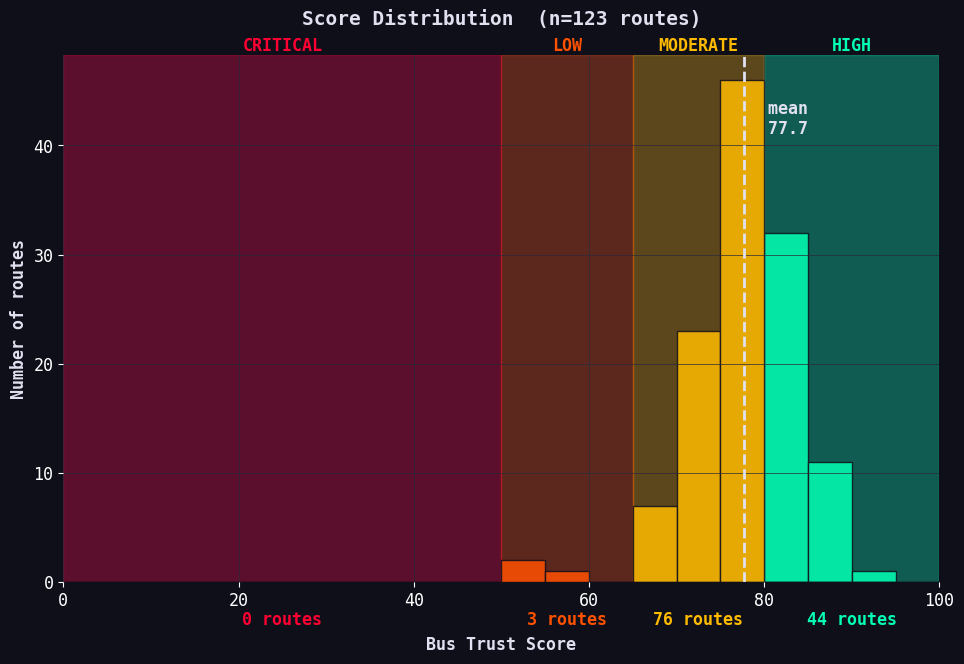

✓ Figure 1 saved


In [7]:
# =============================================================================
# FIGURE 1 — Distribution of Bus Trust Scores
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)

# fig.suptitle('BUS TRUST SCORE DISTRIBUTION', fontsize=20,
#              fontweight='bold', color=WHITE, x=0.02, ha='left', y=1.02)

# ── Histogram with tier shading ──────────────────────────────────────────────
scores = df_sorted['bus_trust_score']

# Tier background bands
tier_bands = [(80,100,GREEN,'HIGH'), (65,80,YELLOW,'MODERATE'),
              (50,65,ORANGE,'LOW'), (0,50,RED,'CRITICAL')]

for lo, hi, col, label in tier_bands:
    ax.axvspan(lo, hi, color=col, alpha=0.3)
    ax.text((lo+hi)/2, 1, label, transform=ax.get_xaxis_transform(),
            ha='center', va='bottom', fontsize=12, color=col,
            fontweight='bold', alpha=1)

# Histogram coloured by tier
bins = np.arange(0, 105, 5)
for lo, hi, col, _ in tier_bands:
    mask = (scores >= lo) & (scores < hi)
    if mask.any():
        ax.hist(scores[mask], bins=bins, color=col, alpha=0.85,
                edgecolor=BG, linewidth=1)

# Mean line
ax.axvline(scores.mean(), color=WHITE, lw=2, ls='--', alpha=1)
ax.text(scores.mean()+0.5, ax.get_ylim()[1]*0.85,
        f'  mean\n  {scores.mean():.1f}',
        color=WHITE, fontsize=12, fontweight='bold')

# Standard deviation lines
mean_score = scores.mean()
std_score  = scores.std()

ax.set_xlabel('\nBus Trust Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of routes', fontsize=12, fontweight='bold')
ax.set_title('Score Distribution  (n=123 routes)\n', color=WHITE, fontsize = 14, fontweight='bold')
ax.set_xlim(0, 100)

# Tier count annotations
for lo, hi, col, label in tier_bands:
    n = ((scores >= lo) & (scores < hi)).sum()
    ax.text((lo+hi)/2, -0.08, f'{n} routes',
            ha='center', fontsize=12, color=col, fontweight='bold',
            transform=ax.get_xaxis_transform())

ax.set_facecolor(PANEL)
ax.tick_params(axis='both', labelsize=12)

plt.tight_layout(pad=2)
plt.savefig('pres_1_trust_distribution.png', dpi=1000,
            bbox_inches='tight', facecolor=BG)
plt.show()

print("✓ Figure 1 saved")

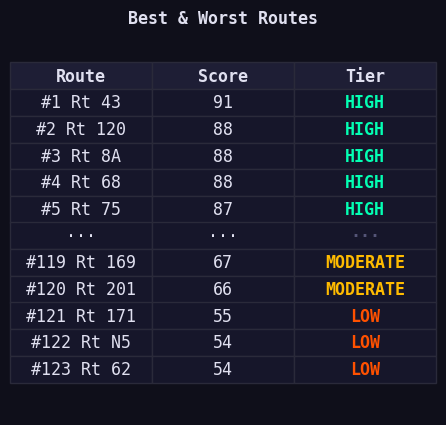

✓ Summary dashboard saved


In [8]:
# ── Top/Bottom 5 table ────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(5, 5), facecolor=BG)

ax.set_facecolor(PANEL)
ax.axis('off')

table_data = []
for _, row in df_sorted.head(5).iterrows():
    table_data.append([f"#{row['rank']} Rt {row['route_id']}",
                       f"{row['bus_trust_score']:.0f}",
                       row['trust_tier']])
table_data.append(['···', '···', '···'])
for _, row in df_sorted.tail(5).iterrows():
    table_data.append([f"#{row['rank']} Rt {row['route_id']}",
                       f"{row['bus_trust_score']:.0f}",
                       row['trust_tier']])

col_labels = ['Route', 'Score', 'Tier']
tbl = ax.table(cellText=table_data, colLabels=col_labels,
                  loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1.1, 1.6)

tier_color_map = {'HIGH': GREEN, 'MODERATE': YELLOW,
                  'LOW': ORANGE, 'CRITICAL': RED, '···': GREY}
for (row_i, col_i), cell in tbl.get_celld().items():
    cell.set_facecolor(PANEL)
    cell.set_edgecolor('#2a2a3a')
    cell.set_text_props(color=WHITE)
    if row_i == 0:
        cell.set_facecolor('#1e1e35')
        cell.set_text_props(color=WHITE, fontweight='bold', fontsize=12)
    if col_i == 2 and row_i > 0:
        tier_val = table_data[row_i - 1][2]
        cell.set_text_props(color=tier_color_map.get(tier_val, WHITE),
                            fontweight='bold')

ax.set_title('Best & Worst Routes', color=WHITE, fontsize=12, pad=5, fontweight='bold')

plt.savefig('pres_2_best&worst_routes.png', dpi=1000, bbox_inches='tight', facecolor=BG)
plt.show()
print("✓ Summary dashboard saved")

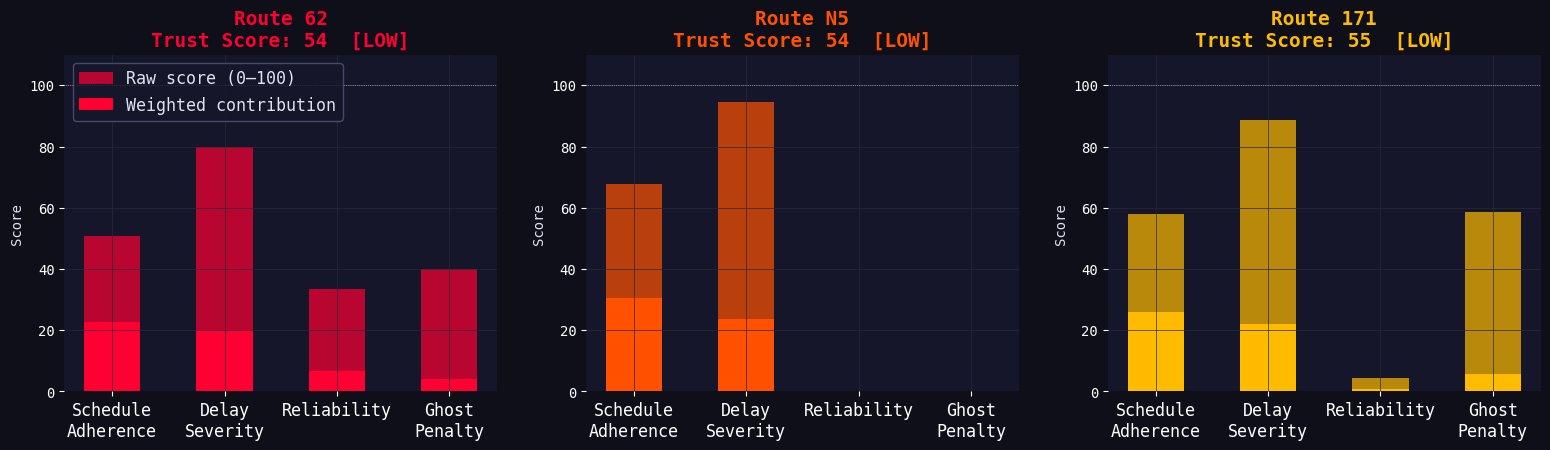

✓ Figure 3 saved


In [9]:
# =============================================================================
# FIGURE 2 — Worst 3 Routes: Metric Breakdown
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor=BG)

ROUTE_COLORS = [RED, ORANGE, YELLOW]

for col_i, (route_id, rcolor) in enumerate(zip(WORST3, ROUTE_COLORS)):
    row_data = df[df['route_id'] == route_id].iloc[0]
    rclean   = clean[clean['route_id'] == route_id].copy()

    # ── Top row: radar / pillar bar ───────────────────────────────────────
    ax_top = axes[col_i]

    pillars = ['Schedule\nAdherence', 'Delay\nSeverity',
               'Reliability', 'Ghost\nPenalty']
    scores_p = [row_data['p_otp'], row_data['p_severity'],
                row_data['p_reliability'], row_data['p_ghost']]
    weights  = [0.45, 0.25, 0.20, 0.10]
    contrib  = [s*w for s,w in zip(scores_p, weights)]

    x_p = np.arange(len(pillars))

    bars = ax_top.bar(x_p, scores_p, color=rcolor, alpha=0.7,
                      width=0.5, label='Raw score (0–100)')
    ax_top.bar(x_p, contrib, color=rcolor, alpha=1,
               width=0.5, label='Weighted contribution')

    ax_top.set_xticks(x_p)
    ax_top.set_xticklabels(pillars, fontsize=12)
    ax_top.set_ylim(0, 110)
    ax_top.set_ylabel('Score')

    ax_top.set_title(
        f'Route {route_id}\n'
        f'Trust Score: {row_data["bus_trust_score"]:.0f}  [{row_data["trust_tier"]}]',
        color=rcolor, fontsize=14, fontweight='bold')

    ax_top.axhline(100, color=WHITE, lw=0.5, ls=':', alpha=1)

    # Score label box
    # ax_top.text(0.97, 0.97,
    #             f'OTP: {row_data["overall_otp_pct"]:.1f}%\n'
    #             f'Std: {row_data["overall_delay_std"]:.1f} min\n'
    #             f'Ghost: {row_data["ghost_rate_pct"]:.1f}%',
    #             transform=ax_top.transAxes, ha='right', va='top',
    #             color=WHITE, fontsize=12,
    #             bbox=dict(boxstyle='round,pad=0.4',
    #                       facecolor=PANEL, edgecolor=rcolor, alpha=0.9))

    if col_i == 0:
        ax_top.legend(fontsize=12, facecolor=PANEL,
                      edgecolor=GREY, labelcolor=WHITE, loc='upper left')

# Apply background to all panels
for ax_ in axes.flat:
    ax_.set_facecolor(PANEL)
    ax.tick_params(axis='both', labelsize=12, labelcolor=WHITE)

plt.tight_layout(pad=2.5)
plt.savefig('pres_3_worst_routes.png', dpi=1000,
            bbox_inches='tight', facecolor=BG)
plt.show()

print("✓ Figure 3 saved")

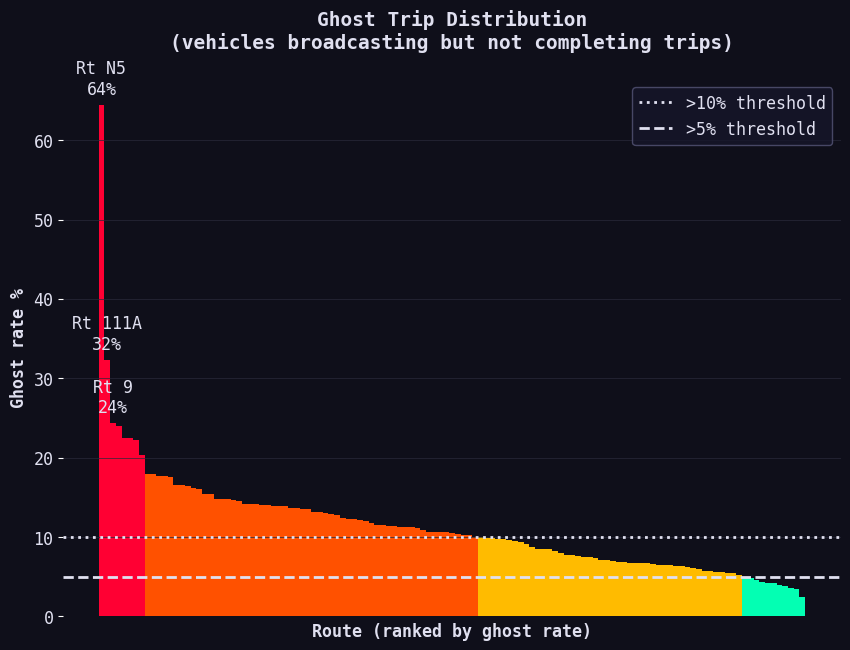

✓ Figure 4 saved


In [10]:
## Ghost Rates

fig, ax = plt.subplots(figsize=(9, 7), facecolor=BG)

# Ghost Bus Plot
ax_c = ax

ghost_sorted = df.sort_values('ghost_rate_pct', ascending=False).reset_index(drop=True)
x = np.arange(len(ghost_sorted))

ghost_colors = [RED if g > 20 else ORANGE if g > 10 else YELLOW if g > 5 else GREEN
                for g in ghost_sorted['ghost_rate_pct']]
ax.bar(x, ghost_sorted['ghost_rate_pct'], color=ghost_colors, alpha=1, width=1.0)

# Annotate top offenders
for i, row in ghost_sorted[ghost_sorted['ghost_rate_pct'] > 24].iterrows():
    ax.text(i, row['ghost_rate_pct'] + 0.8,
              f"Rt {row['route_id']}\n{row['ghost_rate_pct']:.0f}%",
              ha='center', va='bottom', color=WHITE, fontsize=12)

ax.axhline(10, color=WHITE, lw=2, ls='dotted', alpha=1, label='>10% threshold')
ax.axhline(5,  color=WHITE, lw=2, ls='--', alpha=1, label='>5% threshold')
ax.set_xlabel('Route (ranked by ghost rate)', fontsize=12, fontweight='bold')
ax.set_ylabel('Ghost rate %', fontsize=12, fontweight='bold')
ax.set_title('Ghost Trip Distribution\n(vehicles broadcasting but not completing trips)\n',
               color=WHITE, fontsize=14, fontweight='bold')
ax.tick_params(axis='both', labelsize=12, labelcolor=WHITE)
ax.legend(fontsize=12, facecolor=PANEL, edgecolor=GREY, labelcolor=WHITE)
ax.set_xticks([])

plt.tight_layout(pad=2.5)
plt.savefig('pres_4_ghost_distribution.png', dpi=1000,
            bbox_inches='tight', facecolor=BG)
plt.show()

print("✓ Figure 4 saved")

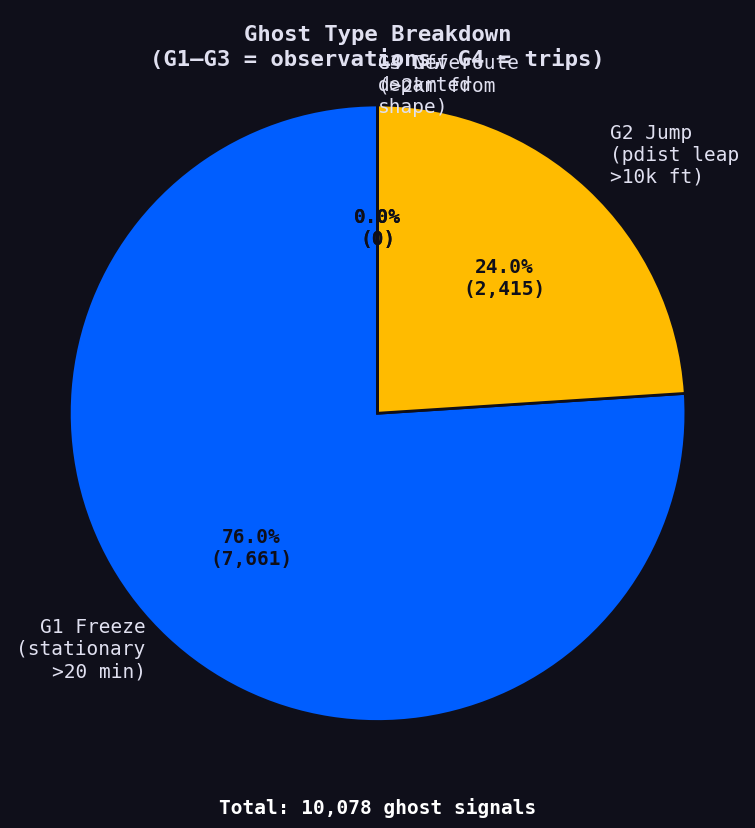

✓ Figure saved


In [11]:
# =============================================================================
# FIGURE — Ghost Type Breakdown
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 8), facecolor=BG)

ghost_obs = result[result['is_ghost']]
g1 = ghost_obs['ghost_freeze'].sum()
g2 = ghost_obs['ghost_jump'].sum()
g3 = ghost_obs['ghost_offroute'].sum()
g4 = (ghost_obs['match_type'] == 'ghost_trip').sum()

labels_g = ['G1 Freeze\n(stationary\n>20 min)\n',
            'G2 Jump\n(pdist leap\n>10k ft)\n',
            '\n\nG3 Off-route\n(>2km from\nshape)\n',
            'G4 Never\ndeparted']

values_g = [g1, g2, g3, g4]
colors_g = [BLUE, YELLOW, ORANGE, RED]

wedges, texts, autotexts = ax.pie(
    values_g,
    labels=labels_g,
    colors=colors_g,
    autopct=lambda p: f'{p:.1f}%\n({int(p/100*sum(values_g)):,})',
    startangle=90,
    wedgeprops=dict(width=1, edgecolor=BG, linewidth=2),
    textprops=dict(color=WHITE, fontsize=14),
)

for at in autotexts:
    at.set_fontsize(14)
    at.set_color(BG)
    at.set_fontweight('bold')

ax.set_title('Ghost Type Breakdown\n(G1–G3 = observations, G4 = trips)',
             color=WHITE, fontsize=16, fontweight='bold')

total_ghosts = sum(values_g)
ax.text(0, -1.3, f'Total: {total_ghosts:,} ghost signals',
        ha='center', color="#ffffff", fontsize=14, fontweight='bold')

ax.set_facecolor(PANEL)

plt.tight_layout(pad=2)
plt.axis('equal') 
plt.savefig('pres_5_ghost_distribution.png', dpi=1000,
            bbox_inches='tight', facecolor=BG)
plt.show()

print("✓ Figure saved")

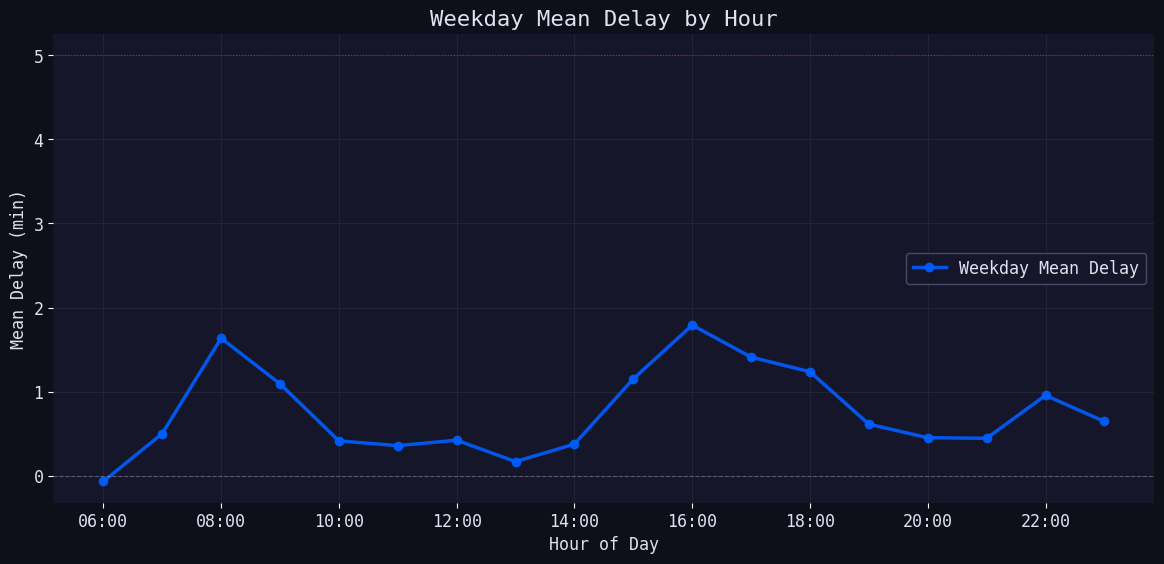

<Figure size 640x480 with 0 Axes>

In [12]:
# Average Accumulated Delay by Hour

import matplotlib.pyplot as plt

# Filter to daytime (optional)
clean_day = clean[clean['hour'] >= 6].copy()

# Compute weekday mean delay by hour
hourly_mean_wd = (clean_day[~clean_day['is_weekend']]
                  .groupby('hour')['delay_minutes']
                  .mean())

# Create figure
fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
ax.plot(hourly_mean_wd.index, hourly_mean_wd.values,
        color=BLUE, lw=2.5, marker='o', markersize=6,
        label='Weekday Mean Delay', alpha=0.9)

# Horizontal reference lines
ax.axhline(0, color=WHITE, lw=0.8, ls='--', alpha=0.3)
ax.axhline(5, color=RED, lw=0.8, ls=':', alpha=1)  # Late threshold

# Axis labels and title
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Mean Delay (min)', fontsize=12)
ax.set_xticks(range(6, 24, 2))
ax.set_xticklabels([f'{h:02d}:00' for h in range(6, 24, 2)], fontsize=12)
ax.set_title('Weekday Mean Delay by Hour', fontsize=16, color=WHITE)

# Background color
ax.set_facecolor(PANEL)

# Legend
ax.legend(fontsize=12, facecolor=PANEL, edgecolor=GREY, labelcolor=WHITE)
ax.tick_params(axis='both', labelsize=12, labelcolor=WHITE)

plt.tight_layout(pad=2)
plt.show()

plt.savefig('pres_6_weekly_mean_delay_by_hour.png', dpi=1000,
            bbox_inches='tight', facecolor=BG)
plt.show()

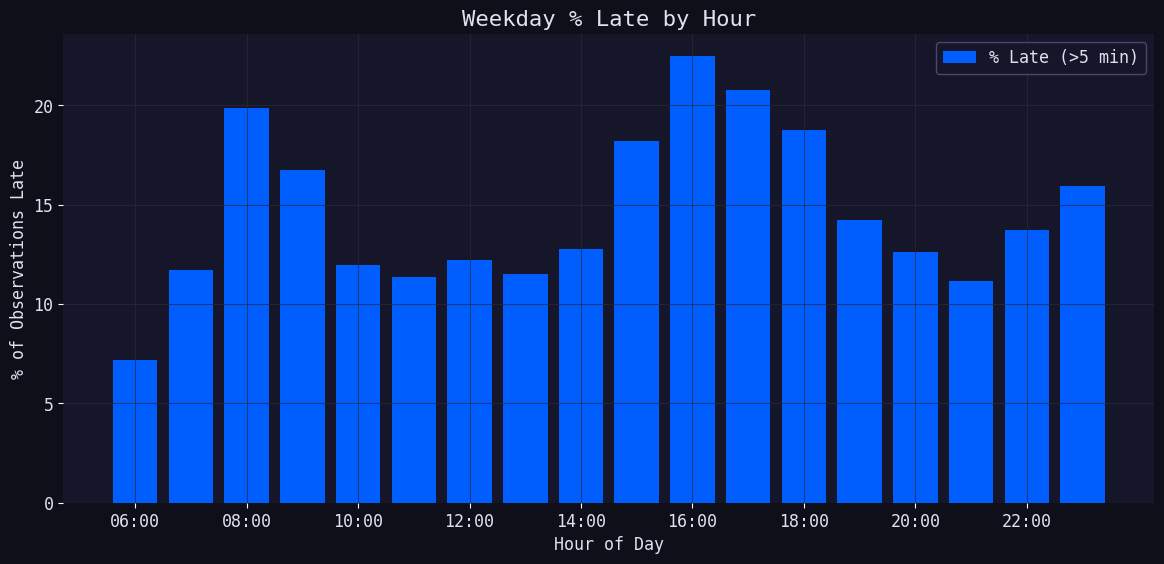

<Figure size 640x480 with 0 Axes>

In [13]:
# =============================================================================
# FIGURE — Weekday % Late by Hour
# =============================================================================

# Filter to daytime and weekdays
clean_day = clean[clean['hour'] >= 6].copy()
weekday_data = clean_day[~clean_day['is_weekend']]

# Compute % late by hour
hourly_pct_late_wd = (weekday_data.groupby('hour')['delay_minutes']
                      .apply(lambda x: (x > 5).mean() * 100))

# Create figure
fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)

# Plot bars
bar_w = 0.8
ax.bar(hourly_pct_late_wd.index, hourly_pct_late_wd.values,
       width=bar_w, color=BLUE, alpha=1, label='% Late (>5 min)')

# Labels & title
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('% of Observations Late', fontsize=12)
ax.set_xticks(range(6, 24, 2))
ax.set_xticklabels([f'{h:02d}:00' for h in range(6, 24, 2)], fontsize=12)
ax.set_title('Weekday % Late by Hour', fontsize=16, color=WHITE)

# Background
ax.set_facecolor(PANEL)

# Legend
ax.legend(fontsize=12, facecolor=PANEL, edgecolor=GREY, labelcolor=WHITE)
ax.tick_params(axis='both', labelsize=12, labelcolor=WHITE)

plt.tight_layout(pad=2)
plt.show()

plt.savefig('pres_6_weekly_mean_delay_by_hour.png', dpi=1000,
            bbox_inches='tight', facecolor=BG)

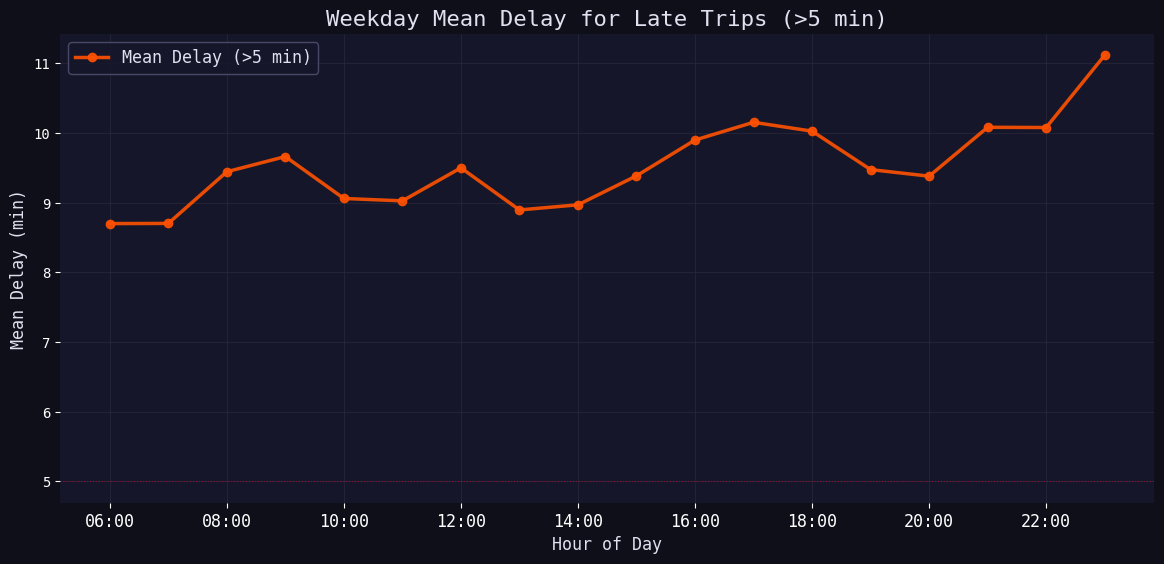

In [14]:
# =============================================================================
# FIGURE — Weekday Mean Delay for Late Trips (>5 min) — Line Plot
# =============================================================================

# Filter to daytime and weekdays
clean_day = clean[clean['hour'] >= 6].copy()
weekday_data = clean_day[~clean_day['is_weekend']]

# Filter only late trips (>5 min)
late_wd = weekday_data[weekday_data['delay_minutes'] > 5]

# Compute mean delay by hour
hourly_mean_late = late_wd.groupby('hour')['delay_minutes'].mean()

# Create figure
fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)

# Plot line
ax.plot(hourly_mean_late.index, hourly_mean_late.values,
        color=ORANGE, lw=2.5, marker='o', markersize=6,
        alpha=0.9, label='Mean Delay (>5 min)')

# Reference line at 5 min threshold (optional)
ax.axhline(5, color=RED, lw=0.8, ls=':', alpha=0.5)

# Labels & title
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Mean Delay (min)', fontsize=12)
ax.set_xticks(range(6, 24, 2))
ax.set_xticklabels([f'{h:02d}:00' for h in range(6, 24, 2)], fontsize=12)
ax.set_title('Weekday Mean Delay for Late Trips (>5 min)', fontsize=16, color=WHITE)

# Background
ax.set_facecolor(PANEL)

# Legend
ax.legend(fontsize=12, facecolor=PANEL, edgecolor=GREY, labelcolor=WHITE)

plt.tight_layout(pad=2)
plt.show()

# Route 201 Focus

In [15]:
# =============================================================================
# CELL — KPI Deep Dive: 5 pillars, Route 201
# =============================================================================

r201 = clean[clean['route_id'] == '201'].copy()
r201['tmstmp_dt'] = pd.to_datetime(r201['tmstmp'])
r201['hour']      = r201['tmstmp_dt'].dt.hour
r201['dow']       = r201['tmstmp_dt'].dt.day_name()
r201['date']      = r201['tmstmp_dt'].dt.date

DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
TOD_ORDER = ['Early Morning','AM Peak','Midday','PM Peak','Evening']

def get_tod(h):
    if h < 6:   return 'Early Morning'
    if h < 10:  return 'AM Peak'
    if h < 15:  return 'Midday'
    if h < 19:  return 'PM Peak'
    return 'Evening'

r201['tod'] = r201['hour'].apply(get_tod)

# ── OTP buckets with explicit thresholds ─────────────────────────────────────
r201['otp_bucket'] = pd.cut(
    r201['delay_minutes'],
    bins=[-np.inf, -1, 5, 15, np.inf],
    labels=['Early\n(<−1 min)', 'On Time\n(−1 to +5)', 'Late\n(5–15 min)', 'Very Late\n(>15 min)']
)
BUCKET_COLORS = [BLUE, GREEN, ORANGE, RED]
BUCKET_ORDER  = ['Early\n(<−1 min)', 'On Time\n(−1 to +5)',
                 'Late\n(5–15 min)', 'Very Late\n(>15 min)']

print("OTP bucket counts:")
print(r201['otp_bucket'].value_counts().reindex(BUCKET_ORDER))

# ── Ghost rate for 201 (from your ghost df) ───────────────────────────────────
# Assumes `ghosts` DataFrame is in scope with columns: route_id, trip_date, etc.
# If not, use the perf summary:
r201_ghost_rate = perf.loc[perf['route_id']=='201', 'ghost_rate_pct'].values[0]
r201_n_ghosts   = perf.loc[perf['route_id']=='201', 'n_ghost_trips'].values[0]
print(f"\nGhost rate: {r201_ghost_rate:.1f}%  ({r201_n_ghosts:.0f} ghost trips)")

OTP bucket counts:
otp_bucket
Early\n(<−1 min)         232
On Time\n(−1 to +5)     1206
Late\n(5–15 min)         646
Very Late\n(>15 min)     158
Name: count, dtype: int64

Ghost rate: 6.9%  (62 ghost trips)


In [26]:
result[result['route_id'] == '201'].des

290018     Howard Station
290019     Howard Station
290020     Howard Station
290021     Howard Station
290022     Howard Station
                ...      
2594685       Old Orchard
2594686       Old Orchard
2594687       Old Orchard
2594688       Old Orchard
2594689       Old Orchard
Name: des, Length: 2259, dtype: object

In [16]:
# =============================================================================
# AGGREGATE — Median Delay per TOD, grouped by Day
# =============================================================================

# Make sure TOD and date are defined
r201['tmstmp_dt'] = pd.to_datetime(r201['tmstmp'])
r201['hour']      = r201['tmstmp_dt'].dt.hour
r201['date']      = r201['tmstmp_dt'].dt.date

def get_tod(h):
    if h < 6:   return 'Early Morning'
    if h < 10:  return 'AM Peak'
    if h < 15:  return 'Midday'
    if h < 19:  return 'PM Peak'
    return 'Evening'

r201['tod'] = r201['hour'].apply(get_tod)

# Group by day and TOD → compute median delay per TOD for each day
daily_tod_median = (
    r201.groupby(['date','tod'])['delay_minutes']
         .median()
         .reset_index()
)

# Pivot for plotting (rows = date, columns = TOD)
daily_tod_median_pivot = daily_tod_median.pivot(index='date', columns='tod', values='delay_minutes')
daily_tod_median_pivot = daily_tod_median_pivot[TOD_ORDER]  # ensure TOD order

print(daily_tod_median_pivot)

tod         Early Morning  AM Peak  Midday  PM Peak  Evening
date                                                        
2026-02-20            NaN      NaN     NaN     1.60    14.25
2026-02-21            NaN      NaN     NaN     5.00    13.80
2026-02-23            NaN     5.20     NaN     1.10    -4.80
2026-02-24            3.2     2.80    8.30      NaN      NaN
2026-02-25            NaN     2.45    5.25      NaN      NaN
2026-02-26            NaN    18.65     NaN      NaN      NaN
2026-02-27            NaN      NaN     NaN      NaN    24.00
2026-02-28            NaN     1.20    2.20     9.05      NaN
2026-03-02            NaN      NaN     NaN      NaN     3.40
2026-03-03            3.2     3.00     NaN      NaN     0.50
2026-03-04            1.8     6.25    6.00      NaN      NaN
2026-03-05            NaN     8.30    3.75      NaN      NaN
2026-03-06            2.0     3.00   -1.00      NaN      NaN


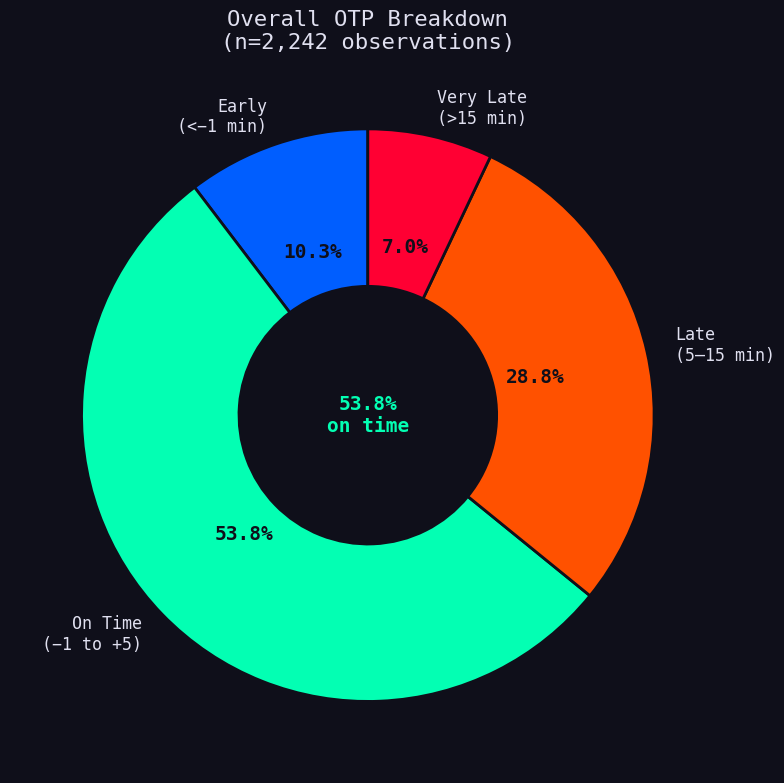

In [17]:
# =============================================================================
# FIGURE — Overall OTP Bucket Breakdown (Donut)
# =============================================================================

# Compute counts
bucket_counts = r201['otp_bucket'].value_counts().reindex(BUCKET_ORDER)
on_time_pct = bucket_counts['On Time\n(−1 to +5)'] / bucket_counts.sum() * 100

# Create figure
fig, ax = plt.subplots(figsize=(8, 8), facecolor=BG)

# Donut plot
wedges, texts, autotexts = ax.pie(
    bucket_counts,
    labels=BUCKET_ORDER,
    colors=BUCKET_COLORS,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor=BG, linewidth=2),
    textprops=dict(color=WHITE, fontsize=12)
)

# Style the percentage labels
for at, col in zip(autotexts, BUCKET_COLORS):
    at.set_color(BG)
    at.set_fontweight('bold')
    at.set_fontsize(14)

# Title
ax.set_title(f'Overall OTP Breakdown\n(n={bucket_counts.sum():,} observations)',
             color=WHITE, fontsize=16)

# Centre annotation for "On Time" percentage
ax.text(0, 0, f'{on_time_pct:.1f}%\non time',
        ha='center', va='center', color=GREEN,
        fontsize=14, fontweight='bold')

# Background
ax.set_facecolor(PANEL)

plt.tight_layout()
plt.show()

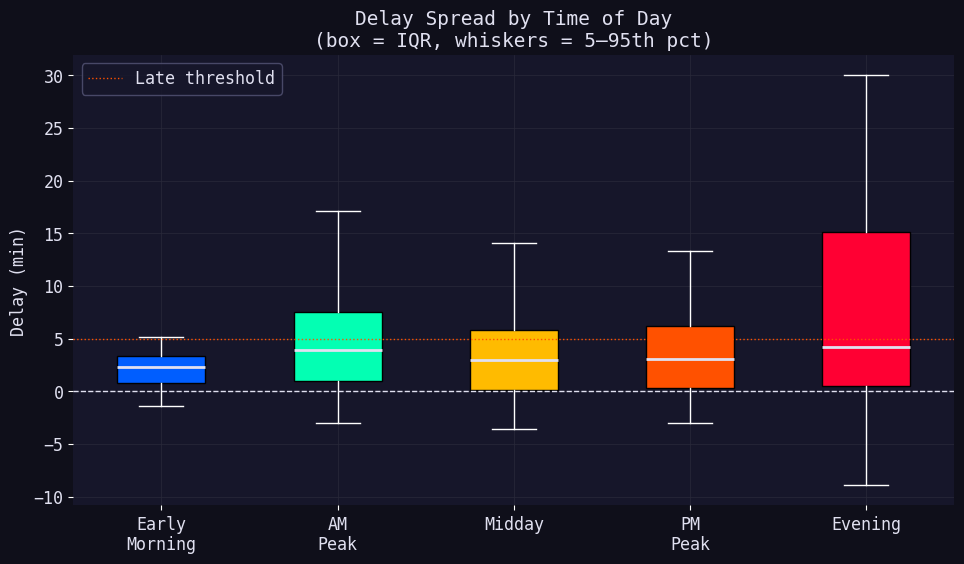

In [18]:
# =============================================================================
# FIGURE — Trip-level Delay Distribution by TOD (Boxplot)
# =============================================================================
TOD_COLORS = [BLUE, GREEN, YELLOW, ORANGE, RED]
# Prepare data
bp_data = [r201[r201['tod'] == t]['delay_minutes'].clip(-15, 30).dropna()
           for t in TOD_ORDER]

# Create figure
fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)

# Boxplot
bp = ax.boxplot(bp_data,
                patch_artist=True,
                notch=False,
                medianprops=dict(color=WHITE, lw=2),
                whiskerprops=dict(color="#FFFFFF"),
                capprops=dict(color="#FFFFFF"),
                flierprops=dict(marker='.', color='#555577',
                                markersize=0, alpha=1))

# Color boxes
for patch, col in zip(bp['boxes'], TOD_COLORS):
    patch.set_facecolor(col)
    patch.set_alpha(1)

# X-axis
ax.set_xticklabels([t.replace(' ', '\n') for t in TOD_ORDER], fontsize=12)

# Y-axis and title
ax.set_ylabel('Delay (min)', fontsize=12)
ax.set_title('Delay Spread by Time of Day\n(box = IQR, whiskers = 5–95th pct)',
             color=WHITE, fontsize=14)

# Reference lines
ax.axhline(0, color=WHITE, lw=1, ls='--', alpha=1)
ax.axhline(5, color=ORANGE, lw=1, ls=':', alpha=1, label='Late threshold')

# Legend
ax.legend(fontsize=12, facecolor=PANEL, edgecolor=GREY, labelcolor=WHITE)
ax.tick_params(axis='both', labelsize=12, labelcolor=WHITE)

# Background
ax.set_facecolor(PANEL)

plt.tight_layout(pad=2)
plt.show()

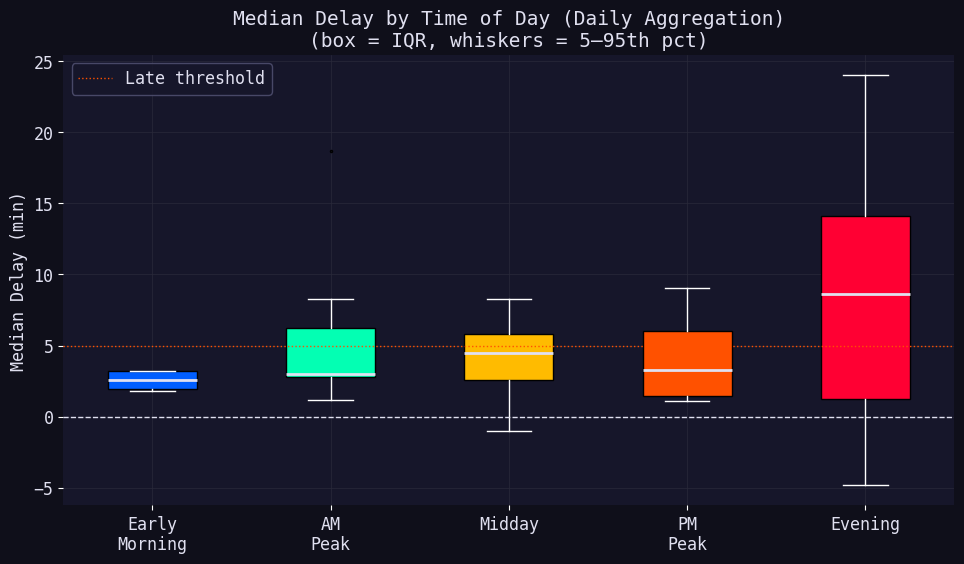

In [19]:
# =============================================================================
# FIGURE — Median Delay by TOD (Daily Aggregation) Boxplot
# =============================================================================
TOD_COLORS = [BLUE, GREEN, YELLOW, ORANGE, RED]

# Prepare data: daily medians per TOD
bp_data_grouped = [daily_tod_median_pivot[t].dropna() for t in TOD_ORDER]

# Create figure
fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)

# Boxplot
bp = ax.boxplot(bp_data_grouped,
                patch_artist=True,
                notch=False,
                medianprops=dict(color=WHITE, lw=2),
                whiskerprops=dict(color="#FFFFFF"),
                capprops=dict(color="#FFFFFF"),
                flierprops=dict(marker='.', color="#000000",
                                markersize=3, alpha=1))

# Color boxes
for patch, col in zip(bp['boxes'], TOD_COLORS):
    patch.set_facecolor(col)
    patch.set_alpha(1)

# X-axis
ax.set_xticklabels([t.replace(' ', '\n') for t in TOD_ORDER], fontsize=12)

# Y-axis and title
ax.set_ylabel('Median Delay (min)', fontsize=12)
ax.set_title('Median Delay by Time of Day (Daily Aggregation)\n(box = IQR, whiskers = 5–95th pct)',
             color=WHITE, fontsize=14)

# Reference lines
ax.axhline(0, color=WHITE, lw=1, ls='--', alpha=1)
ax.axhline(5, color=ORANGE, lw=1, ls=':', alpha=1, label='Late threshold')

# Legend
ax.legend(fontsize=12, facecolor=PANEL, edgecolor=GREY, labelcolor=WHITE)

# Background
ax.set_facecolor(PANEL)
ax.tick_params(axis='both', labelsize=12, labelcolor=WHITE)

plt.tight_layout(pad=2)
plt.show()

In [20]:
# =============================================================================
# ROUTE 201 — Stop-Level OTP Analysis
# =============================================================================

# Define the stops of interest
STOPS_OF_INTEREST = {
    '18354': 'Sheridan & Emerson NB',
    '17296': 'Sheridan & Foster NB',
    '17295': 'Sheridan & Foster SB',
    '18355': 'Sheridan & Haven NB',
    '18357': 'Sheridan & Haven SB',
    '18356': 'Sheridan & Lincoln NB',
    '17301': 'Sheridan & Lincoln SB',
}

# Check what stop columns we have
stop_cols = [c for c in clean.columns if any(x in c.lower()
             for x in ['stop','stpid','stpnm','next','prev'])]
print("Stop-related columns:", stop_cols)
print("\nSample prev_stop_name values:")
print(r201['prev_stop_name'].value_counts().head(10))
print("\nSample next_stop_name values:")
print(r201['next_stop_name'].value_counts().head(10))

Stop-related columns: ['stop_id', 'first_stop_name', 'scheduled_departure_stop1', 'prev_stop_name', 'next_stop_name']

Sample prev_stop_name values:
prev_stop_name
Old Orchard Rd & Skokie Blvd        150
Rogers & Hermitage                  114
Paulina & Howard Terminal            83
Howard & Ridge                       66
Church & Chicago Avenue              66
Sheridan & Lincoln                   59
4700 W Old Orchard Rd                55
Sheridan & Haven                     54
Sheridan & Foster                    53
Old Orchard Mall - Bloomingdales     51
Name: count, dtype: int64

Sample next_stop_name values:
next_stop_name
Old Orchard Mall - Macys        142
Paulina & Howard Terminal       114
Howard & Chicago Avenue          83
Old Orchard Rd & Skokie Blvd     71
Central Street & Crawford        69
Sheridan & Emerson               66
Sheridan & Lincoln               60
Sheridan & Haven                 59
Howard & Ridge                   56
Ridge & Brummel                  54
Name

In [21]:
# =============================================================================
# ROUTE 201 — Stop-Level OTP  (Sheridan corridor)
# =============================================================================

STOPS = {
    'Sheridan & Emerson':  ('NB', 'Emerson'),
    'Sheridan & Foster':   ('NB/SB', 'Foster'),
    'Sheridan & Haven':    ('NB/SB', 'Haven'),
    'Sheridan & Lincoln':  ('NB/SB', 'Lincoln'),
}

from matplotlib.collections import LineCollection
import matplotlib.dates as mdates

fig = plt.figure(figsize=(22, 18), facecolor=BG)
fig.suptitle('ROUTE 201  ·  Evanston',
             fontsize=18, fontweight='bold', color=WHITE,
             x=0.02, ha='left', y=1.005)
fig.text(0.02, 0.997, '9-day window  ·  Feb 20–28 2026  ·  14,465 observations  ·  136 trips',
         color='#888899', fontsize=10, va='top')

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.38)

# ─── colour helpers ───────────────────────────────────────────────────────────
def delay_color(d):
    if d < -1:  return GREEN
    if d <= 3:  return YELLOW
    if d <= 8:  return ORANGE
    return RED

TOD_ORDER  = ['Early Morning', 'AM Peak', 'Midday', 'PM Peak', 'Evening']
TOD_COLORS = [BLUE, GREEN, YELLOW, ORANGE, RED]
tod_cmap   = dict(zip(TOD_ORDER, TOD_COLORS))

# We use next_stop_name == stop to get obs *approaching* that stop,
# and prev_stop_name == stop to get obs *just departed* that stop.
# Combining both gives the fullest picture of delay at that location.

r201_stops = r201[
    r201['next_stop_name'].isin(STOPS.keys()) |
    r201['prev_stop_name'].isin(STOPS.keys())
].copy()

r201_stops['stop_name'] = np.where(
    r201_stops['next_stop_name'].isin(STOPS.keys()),
    r201_stops['next_stop_name'],
    r201_stops['prev_stop_name']
)
r201_stops['at_stop_type'] = np.where(
    r201_stops['next_stop_name'].isin(STOPS.keys()),
    'approaching', 'departed'
)

print("Observations per stop:")
print(r201_stops.groupby(['stop_name','at_stop_type']).size().unstack(fill_value=0))
print("\nDelay summary per stop:")
print(r201_stops.groupby('stop_name')['delay_minutes']
      .agg(['count','median','mean','std'])
      .round(2))

Observations per stop:
at_stop_type        approaching  departed
stop_name                                
Sheridan & Emerson           66         0
Sheridan & Foster            33        22
Sheridan & Haven             59         0
Sheridan & Lincoln           60        31

Delay summary per stop:
                    count  median  mean   std
stop_name                                    
Sheridan & Emerson     66     5.1  6.47  4.97
Sheridan & Foster      55     2.7  4.23  7.35
Sheridan & Haven       59     4.8  5.53  6.50
Sheridan & Lincoln     91     5.1  6.37  6.82


<Figure size 2200x1800 with 0 Axes>

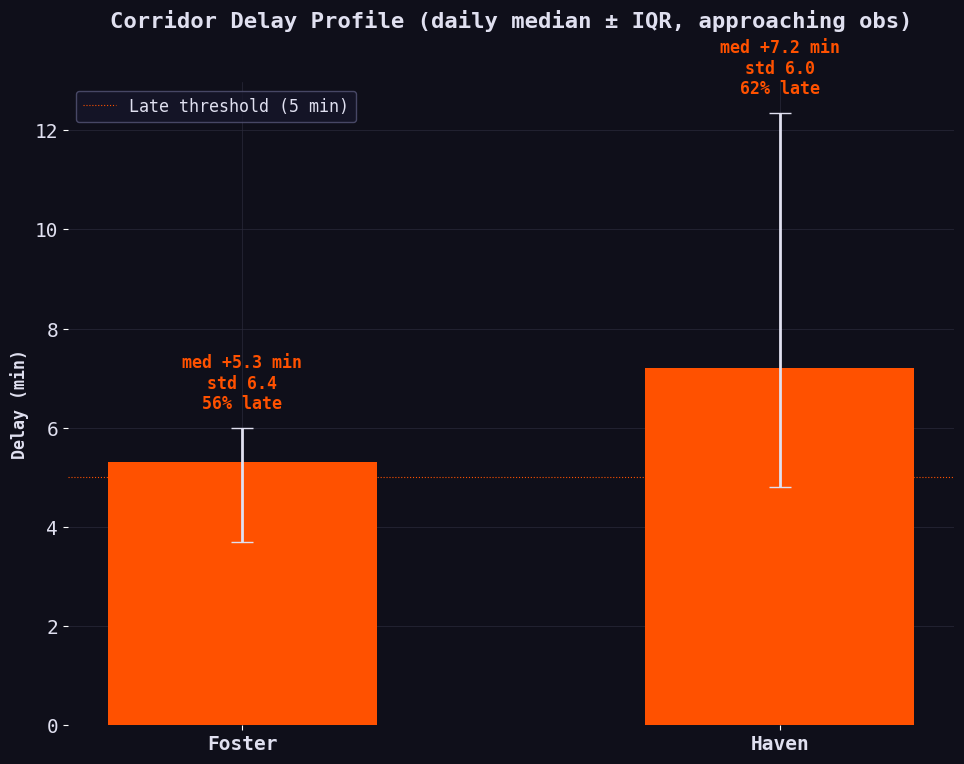

In [32]:
# =============================================================================
# ROUTE 201 — Stop-Level Delay (Daily Median)
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

STOP_ORDER = ['Sheridan & Foster', 'Sheridan & Haven']
STOP_SHORT = ['Foster', 'Haven']

# Aggregate: daily median per stop
r201_appr = r201_stops[r201_stops['at_stop_type'] == 'approaching'].copy()
r201_appr = r201_appr[r201_appr['des'] == 'Old Orchard']
daily_stop_median = (
    r201_appr.groupby(['date','stop_name'])['delay_minutes']
    .median()
    .reset_index()
)

# Compute overall median, IQR, mean, std, % late per stop
stop_stats = (daily_stop_median.groupby('stop_name')['delay_minutes']
              .agg(['median','mean','std',
                    lambda x: x.quantile(0.25),
                    lambda x: x.quantile(0.75),
                    lambda x: (x > 5).mean()*100,
                    lambda x: (x > 15).mean()*100,
                    'count'])
              .reindex(STOP_ORDER))
stop_stats.columns = ['median','mean','std','q25','q75','pct_late','pct_very_late','n']

# Plot
fig = plt.figure(figsize=(10, 8), facecolor=BG)

gs = gridspec.GridSpec(1, 1, figure=fig)

ax_a = fig.add_subplot(gs[0, 0])

x = np.arange(len(STOP_ORDER))
bar_cols = [delay_color(m) for m in stop_stats['median']]
bar_cols = [ORANGE, ORANGE]

# Median bars with IQR error bars
ax_a.bar(x, stop_stats['median'], color=bar_cols, alpha=1, width=0.5, zorder=3)
ax_a.errorbar(x, stop_stats['median'],
              yerr=[stop_stats['median'] - stop_stats['q25'],
                    stop_stats['q75'] - stop_stats['median']],
              fmt='none', color=WHITE, capsize=8, lw=2, zorder=4)

# Annotations
for i, (s, row) in enumerate(stop_stats.iterrows()):
    ax_a.text(i, row['median'] + row['q75'] - row['median'] + 0.3,
              f"med {row['median']:+.1f} min\n"
              f"std {row['std']:.1f}\n"
              f"{row['pct_late']:.0f}% late",
              ha='center', va='bottom', fontsize=12,
              color=bar_cols[i], fontweight='bold')
    # ax_a.text(i, -1.5, f"n={row['n']:.0f}", ha='center', fontsize=12, color="#FFFFFF")

# Reference lines
ax_a.axhline(0, color=WHITE,  lw=0.7, ls='--', alpha=1)
ax_a.axhline(5, color=ORANGE, lw=0.8, ls=':', alpha=1, label='Late threshold (5 min)')

# Axes
ax_a.set_xticks(x)
ax_a.set_xticklabels(STOP_SHORT, fontsize=12, fontweight='bold')
ax_a.set_ylabel('Delay (min)', color=WHITE, fontsize=12, fontweight='bold')
ax_a.set_title('Corridor Delay Profile (daily median ± IQR, approaching obs)\n\n',
               color=WHITE, fontsize=16, fontweight='bold')

ax_a.legend(fontsize=12, facecolor=PANEL, edgecolor=GREY, labelcolor=WHITE)
ax_a.tick_params(axis='both', labelsize=14, labelcolor=WHITE)

plt.tight_layout(pad=2)
plt.savefig('pres_10_corridor_delay_profile.png', dpi=1000,
            bbox_inches='tight', facecolor=BG)
plt.show()

In [34]:
metrics = pd.read_csv('metrics_results/final_metrics_dataset.csv')

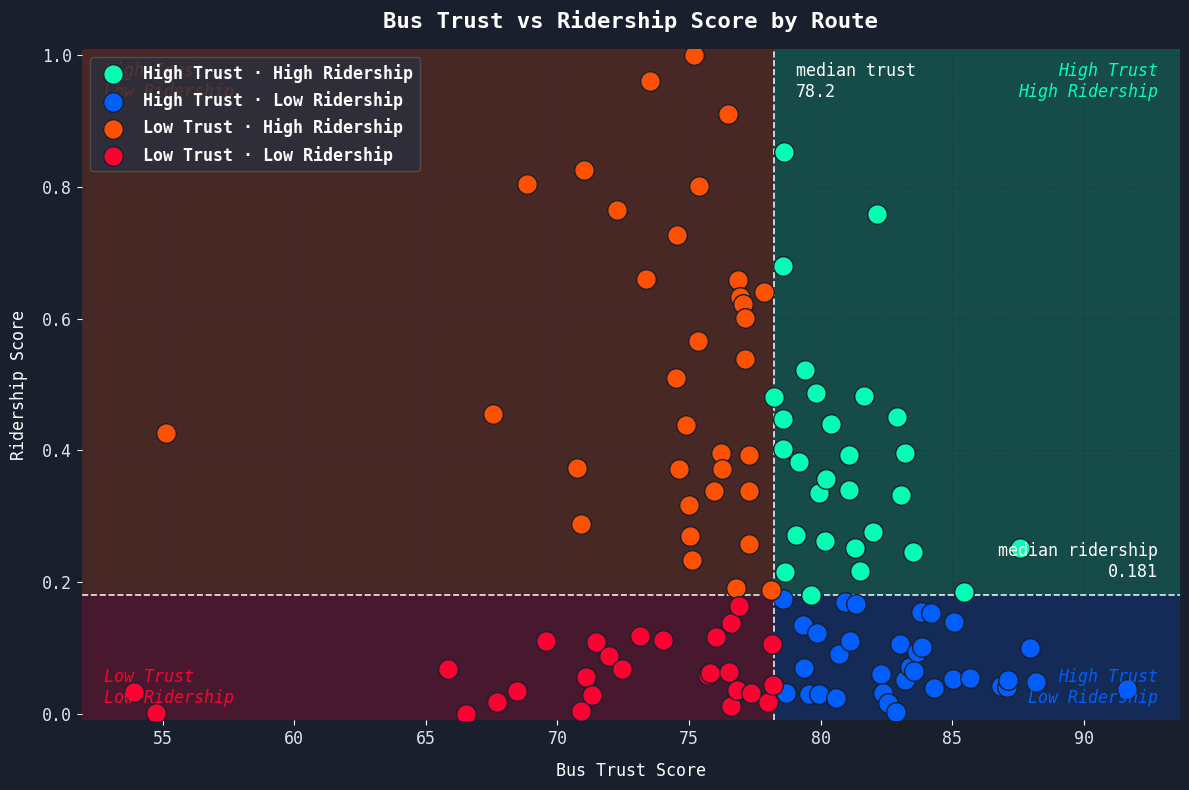

In [38]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df = metrics.copy()

# ── Quadrant thresholds (medians)
trust_mid     = df["bus_trust_score"].median()
ridership_mid = df["ridership_score"].median()

# ── Quadrant assignment
def assign_quadrant(row):
    hi_trust     = row["bus_trust_score"] >= trust_mid
    hi_ridership = row["ridership_score"] >= ridership_mid
    if hi_trust and hi_ridership:
        return "High Trust\nHigh Ridership"
    elif hi_trust and not hi_ridership:
        return "High Trust\nLow Ridership"
    elif not hi_trust and hi_ridership:
        return "Low Trust\nHigh Ridership"
    else:
        return "Low Trust\nLow Ridership"

df["quadrant"] = df.apply(assign_quadrant, axis=1)

# ── Color scheme matching quadrant meaning
quad_colors = {
    "High Trust\nHigh Ridership": GREEN,   # best performers
    "High Trust\nLow Ridership":  BLUE,    # trusted but low use
    "Low Trust\nHigh Ridership":   ORANGE, # popular but unreliable
    "Low Trust\nLow Ridership":    RED,    # needs attention
}

quad_labels = {
    "High Trust\nHigh Ridership":  "High Trust · High Ridership",
    "High Trust\nLow Ridership":   "High Trust · Low Ridership",
    "Low Trust\nHigh Ridership":   "Low Trust · High Ridership",
    "Low Trust\nLow Ridership":    "Low Trust · Low Ridership",
}

# ── Figure setup
BG, PANEL = "#1a1f2e", "#2a2f3e"
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor":   BG,
    "axes.edgecolor":   "#444",
    "axes.labelcolor":  "white",
    "xtick.color":      "white",
    "ytick.color":      "white",
    "text.color":       "white",
    "grid.color":       "#2a2f3e",
    "grid.linestyle":   "--",
    "grid.alpha":       0.6,
})

fig, ax = plt.subplots(figsize=(12, 8))

# ── Quadrant background shading (colors match quadrants)
xlim = (df["bus_trust_score"].min()-2, df["bus_trust_score"].max()+2)
ylim = (df["ridership_score"].min()-0.01, df["ridership_score"].max()+0.01)

shade_quads = [
    (xlim[0], trust_mid,  ylim[0], ridership_mid, RED, 0.2),    # Low Trust / Low Ridership
    (trust_mid, xlim[1],  ylim[0], ridership_mid, BLUE, 0.2), # Low Trust / High Ridership
    (xlim[0], trust_mid,  ridership_mid, ylim[1], ORANGE, 0.2),   # High Trust / Low Ridership
    (trust_mid, xlim[1],  ridership_mid, ylim[1], GREEN, 0.2),  # High Trust / High Ridership
]
for x0, x1, y0, y1, c, a in shade_quads:
    ax.add_patch(mpatches.Rectangle((x0, y0), x1-x0, y1-y0,
                                   facecolor=c, alpha=a, zorder=1))

# ── Scatter points per quadrant (colors match background)
for quad, color in quad_colors.items():
    subset = df[df["quadrant"] == quad]
    ax.scatter(
        subset["bus_trust_score"], subset["ridership_score"],
        c=color, s=200, alpha=1, edgecolors=BG, linewidths=1,
        label=quad_labels[quad], zorder=3
    )

# ── Median crosshair lines
ax.axvline(trust_mid, color="white", lw=1.2, ls="--", alpha=0.9, zorder=2)
ax.axhline(ridership_mid, color="white", lw=1.2, ls="--", alpha=0.9, zorder=2)

# ── Corner labels
pad_x = (xlim[1]-xlim[0])*0.02
pad_y = (ylim[1]-ylim[0])*0.02
corner_labels = [
    (xlim[0]+pad_x, ylim[0]+pad_y, "Low Trust\nLow Ridership",    RED, "left", "bottom"),
    (xlim[1]-pad_x, ylim[0]+pad_y, "High Trust\nLow Ridership",   BLUE, "right", "bottom"),
    (xlim[0]+pad_x, ylim[1]-pad_y, "High Trust\nLow Ridership",   ORANGE, "left", "top"),
    (xlim[1]-pad_x, ylim[1]-pad_y, "High Trust\nHigh Ridership",  GREEN, "right", "top"),
]
for cx, cy, text, color, ha, va in corner_labels:
    ax.text(cx, cy, text, color=color, fontsize=12, alpha=1,
            ha=ha, va=va, fontstyle="italic", zorder=4)

# ── Median labels
ax.text(trust_mid + pad_x, ylim[1]-pad_y, f"median trust\n{trust_mid:.1f}",
        color="white", fontsize=12, alpha=1, ha="left", va="top")
ax.text(xlim[1]-pad_x, ridership_mid+pad_y, f"median ridership\n{ridership_mid:.3f}",
        color="white", fontsize=12, alpha=1, ha="right", va="bottom")

# ── Axes, title, legend
ax.set_xlabel("Bus Trust Score", fontsize=12, labelpad=10)
ax.set_ylabel("Ridership Score", fontsize=12, labelpad=10)
ax.set_title("Bus Trust vs Ridership Score by Route", fontsize=16,
             fontweight="bold", pad=15)

leg = ax.legend(loc="upper left", fontsize=12, facecolor=PANEL, edgecolor="#555", labelcolor="white")
for text in leg.get_texts():
    text.set_fontweight("bold")

ax.grid(True)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.tick_params(axis='both', labelsize=12, labelcolor=WHITE)

plt.tight_layout()
plt.savefig('pres_11_trust_vs_ridership.png', dpi=1000,
            bbox_inches='tight', facecolor=BG)
plt.show()